<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


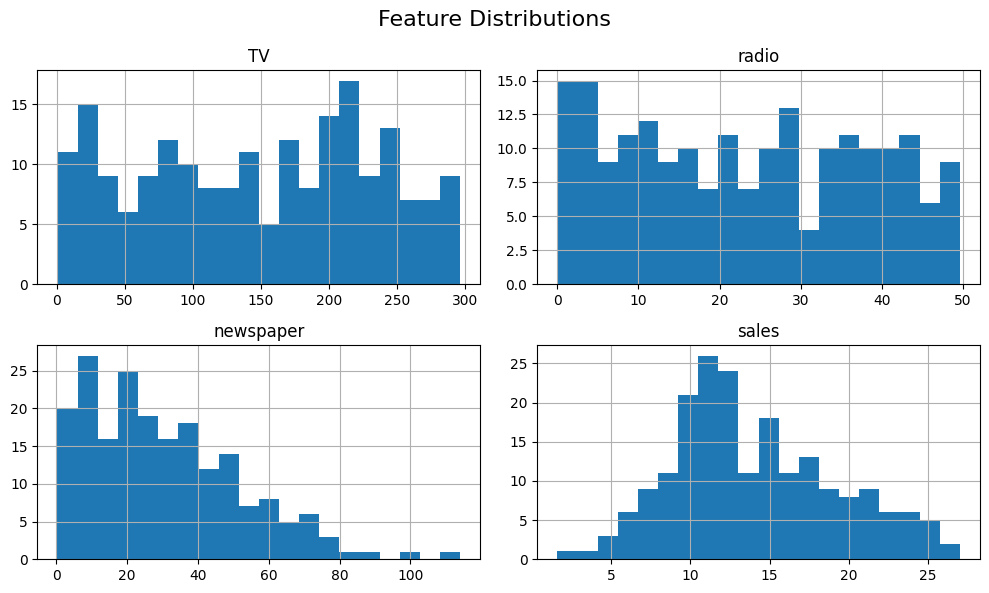

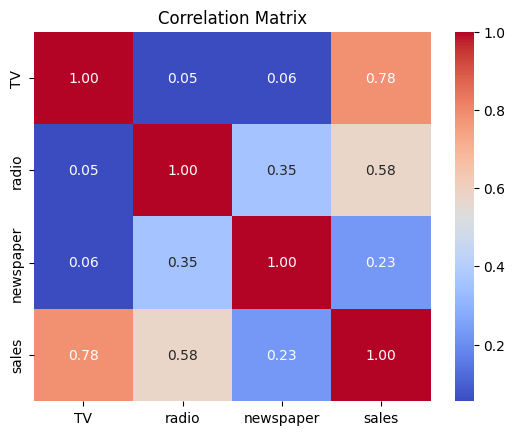

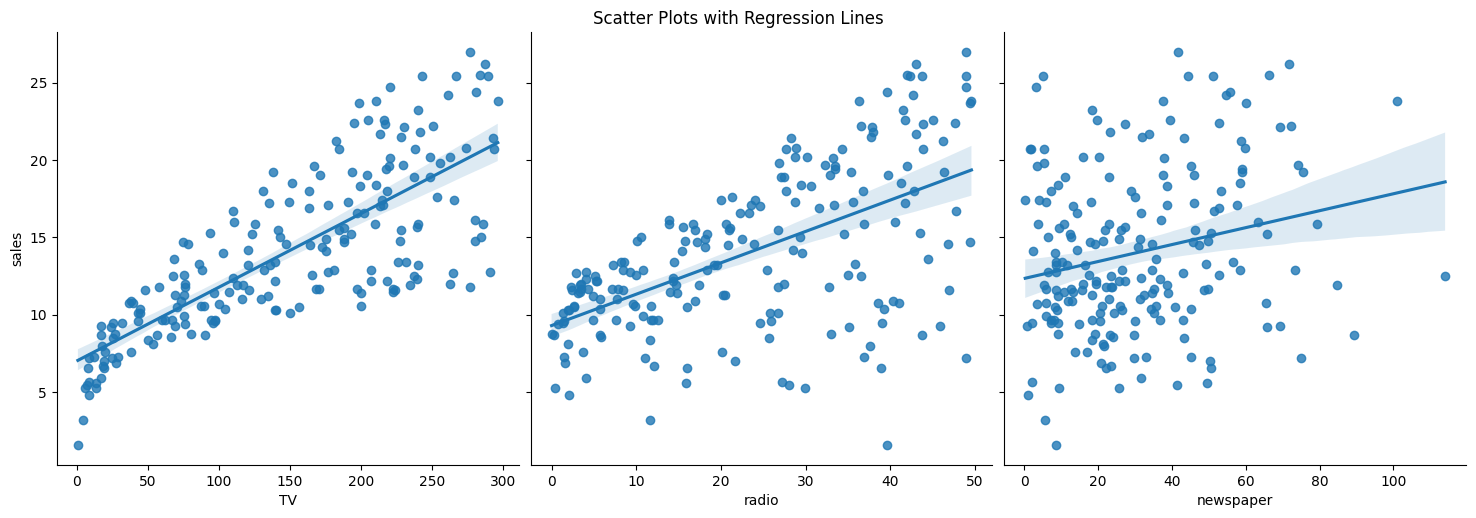

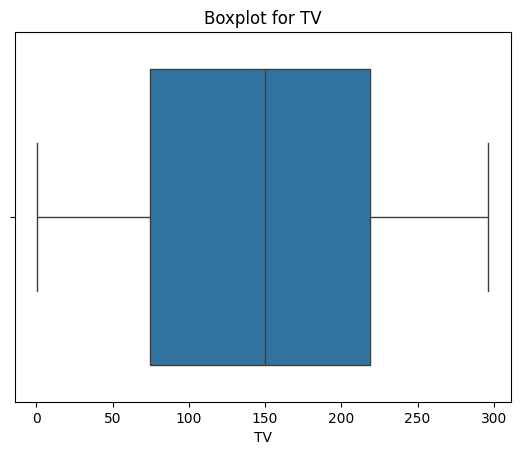

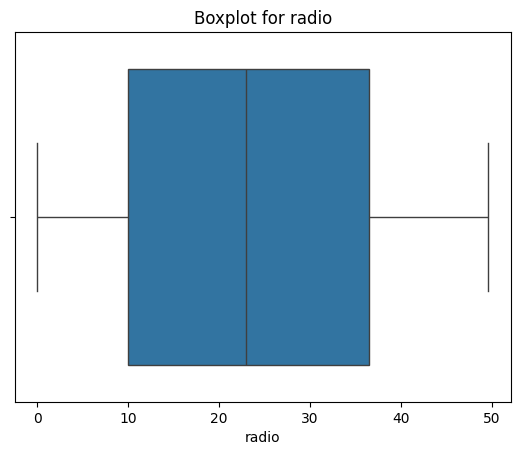

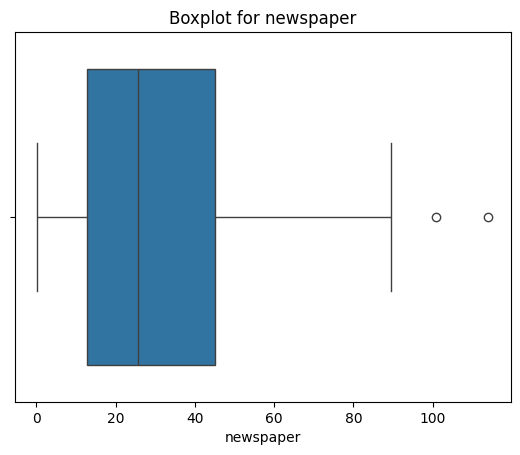

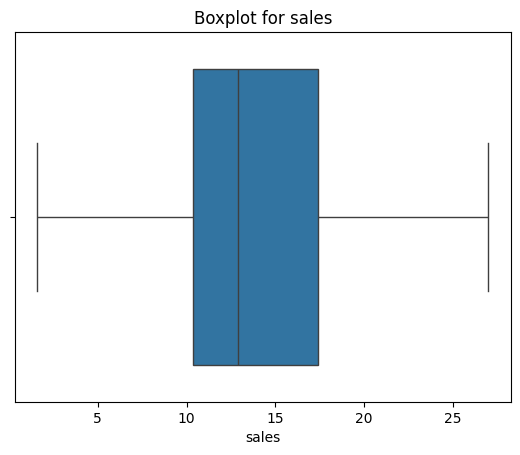

In [38]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Advertising.csv")

df.head()
df.info() # Columns are float type so I didn't had to change them, becuase they would be useful later on for manipulating them.

df.drop(columns = ['Unnamed: 0'], inplace = True) # Had to remove unnecessary blank column

# Check-ups
df.duplicated().sum()
df.isnull().sum()

df.hist(bins=20, figsize=(10, 6))
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

corr_matrix = df.corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

sns.pairplot(df, x_vars=["TV", "radio", "newspaper"], y_vars="sales", kind="reg", height=5)
plt.suptitle("Scatter Plots with Regression Lines", y=1.02)
plt.show()

for column in df.columns:
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot for {column}")
    plt.show()

# Checking the specific outliers found in the newspaper part
Q1 = df['newspaper'].quantile(0.25)
Q3 = df['newspaper'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

df['newspaper'] = np.where(df['newspaper'] > upper_bound, upper_bound, df['newspaper']) #capped the outliers in the newspaper

df.to_csv('advertising_updated.csv', index = False)

In [39]:
from sklearn.preprocessing import StandardScaler

features = df.drop('sales', axis=1)
target = df['sales']

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

X = pd.DataFrame(scaled_features, columns=features.columns)
y = target

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Creating the model
model = LinearRegression()

# Training
model.fit(X_train, y_train)

# Predicting on test set
y_pred = model.predict(X_test)

# Evaluating the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation: ")
print("------------------------------------")
print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"R-squared Score: {r2:.3f}")
print("------------------------------------")

Model Evaluation: 
------------------------------------
Mean Squared Error (MSE): 3.171
Root Mean Squared Error (RMSE): 1.781
R-squared Score: 0.900
------------------------------------


In [42]:
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coefficients)

           Coefficient
TV            3.830819
radio         2.802285
newspaper     0.057980


### **Visualizations of Results**

For Direct Display

In [43]:
%matplotlib inline

Actual versus Predicted Plot

Text(0.5, 1.0, 'Actual vs Predicted Sales (Linear Regression)')

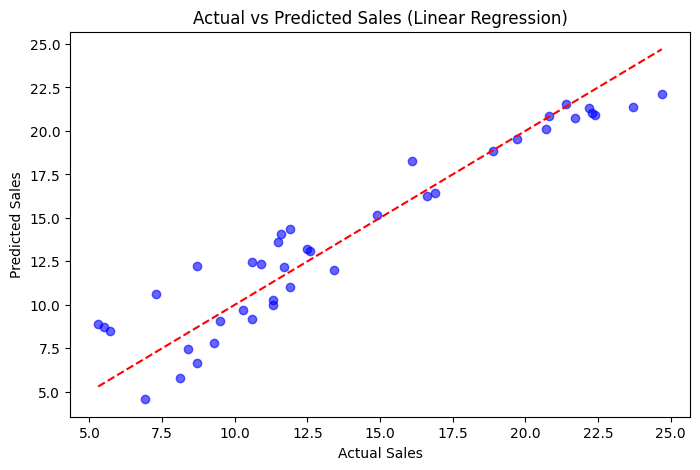

In [44]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales (Linear Regression)")

Coefficient Impact

(array([0, 1, 2]),
 [Text(0, 0, 'TV'), Text(1, 0, 'radio'), Text(2, 0, 'newspaper')])

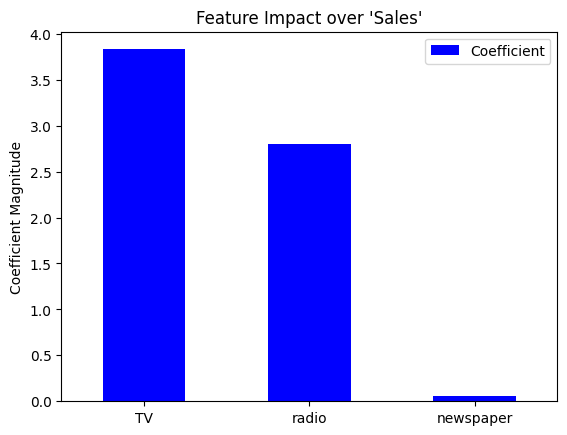

In [45]:
coefficients.plot(kind='bar', color='blue')
plt.title("Feature Impact over 'Sales'")
plt.ylabel("Coefficient Magnitude")
plt.xticks(rotation=0)

Residual Plot

Text(0.5, 1.0, 'Residual Plot')

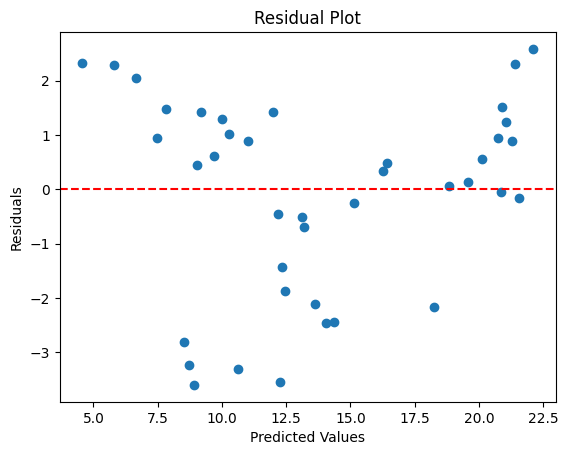

In [46]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

Error Distribution

Text(0.5, 1.0, 'Error Distribution')

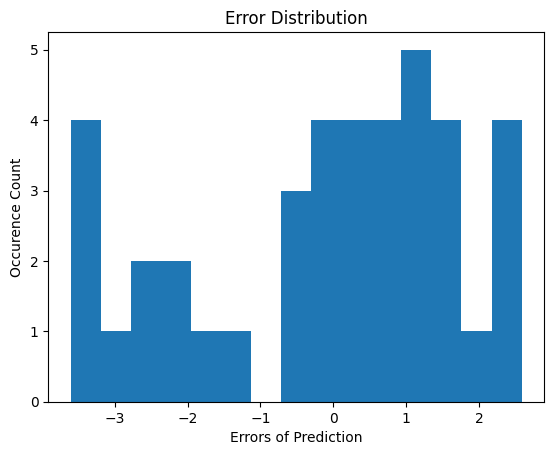

In [47]:
plt.hist(residuals, bins=15)
plt.xlabel("Errors of Prediction")
plt.ylabel("Occurence Count")
plt.title("Error Distribution")

## **Detailed Report**

https://drive.google.com/file/d/10jpahhwJwGaHXdmXRumQ1DYc5vm_ifHa/view?usp=sharing